## 4ª Tarefa de Oficina de Modelagem e Simulação

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 11 de abril de 2026  

---

### Descrição
Exercícios computacionais

---

**1.** *Encontre a resposta à entrada nula de um sistema linear invariante no tempo descrito por
$(p + 5)y(t) = x(t)$ com condição inicial $y(0) = 5.$ Explore o comando **dsolve.***

In [30]:
import sympy as sp

"""
    O sistema com a entrada nula se torna a equação diferencial: y'(t) + 5y(t) = 0.
    Com a condição: y(0) = 5
    (Como estamos em python, aqui usaremos sympy)
"""

# Declaração da variável t
t = sp.symbols('t')
# Declaração da função y
y = sp.Function('y')

# Declaração da equação diferencial y'(t) + 5y(t) = 0
eq = sp.Eq(sp.diff(y(t), t) + 5*y(t), 0)

# Resolver com a condição inicial y(0) = 5 com 'dsolve' 
solução = sp.dsolve(eq, y(t), ics={y(0):5})

# Printa a solução
print("Solução:", solução, "\n")

# Printa a solução simbolicamente
print("Solução simbólica: ")
sp.pprint(solução)

Solução: Eq(y(t), 5*exp(-5*t)) 

Solução simbólica: 
          -5⋅t
y(t) = 5⋅ℯ    


---

**2.** *Resolva $(p^2 + 2p)y(t) = 0$, com $y(0) = 1$ e $y'(0) = 4$*

In [31]:
import sympy as sp

"""
    Temos a equação diferencial: y''(t) + 2y'(t) = 0.
    Com as condições: y(0) = 1 e y'(0) = 4
    (Como estamos em python, aqui usaremos sympy)
"""

# Declaração da variável t
t = sp.symbols('t')

# Declaração da função y(t)
y = sp.Function('y')

# Declaração da equação diferencial y''(t) + 2y'(t) = 0
eq  = sp.Eq(sp.diff(y(t), t, t) + 2*sp.diff(y(t), t), 0)

# Resolução com as condições iniciais
solução = sp.dsolve(eq, y(t), ics={y(0):1, sp.diff(y(t), t).subs(t, 0):4})

# Printa a solução
print("Solução:", solução, "\n")

# Printa a solução simbolicamente
print("Solução simbólica: ")
sp.pprint(solução)


Solução: Eq(y(t), 3 - 2*exp(-2*t)) 

Solução simbólica: 
              -2⋅t
y(t) = 3 - 2⋅ℯ    


---

**3.** *Achar a resposta para a EDO de segunda ordem $\ddot{y} + 3\dot{y} + 2y = 8sen(5t)$, para as condições iniciais $\dot{y}(0) = 0$ e $y(0) = 0$*

In [32]:
import sympy as sp

"""
    Temos a equação diferencial: y''(t) + 3y'(t) + 2y = 8sin(5t).
    Com as condições: y(0) = 0 e y'(0) = 0
    (Como estamos em python, aqui usaremos sympy)
"""

# Declaração da variável t
t = sp.symbols('t')

# Declaração da Função y(t)
y = sp.Function('y')

# Declaração da Equação diferencial y''(t) + 3y'(t) + 2y = 8sin(5t)
eq = sp.Eq(sp.diff(y(t), t, t) + 3*sp.diff(y(t), t) + 2*y(t), 8*sp.sin(5*t))

# Resolução com as condições iniciais
solução = sp.dsolve(eq, y(t), ics={y(0):0, sp.diff(y(t), t).subs(t, 0):0})

# Printa a solução
print("Solução:", solução, "\n")

# Printa a solução simbolicamente
print("Solução simbólica:")
sp.pprint(solução)


Solução: Eq(y(t), -92*sin(5*t)/377 - 60*cos(5*t)/377 + 20*exp(-t)/13 - 40*exp(-2*t)/29) 

Solução simbólica:
                                         -t       -2⋅t
         92⋅sin(5⋅t)   60⋅cos(5⋅t)   20⋅ℯ     40⋅ℯ    
y(t) = - ─────────── - ─────────── + ────── - ────────
             377           377         13        29   


---

**4.** *Achar a resposta para a EDO de segunda ordem $\ddot{y} + 3\dot{y} + e^{-t}y = 8sen(5t)$, para as condições iniciais $\dot{y}(0) = 0$ e $y(0) = 0$*

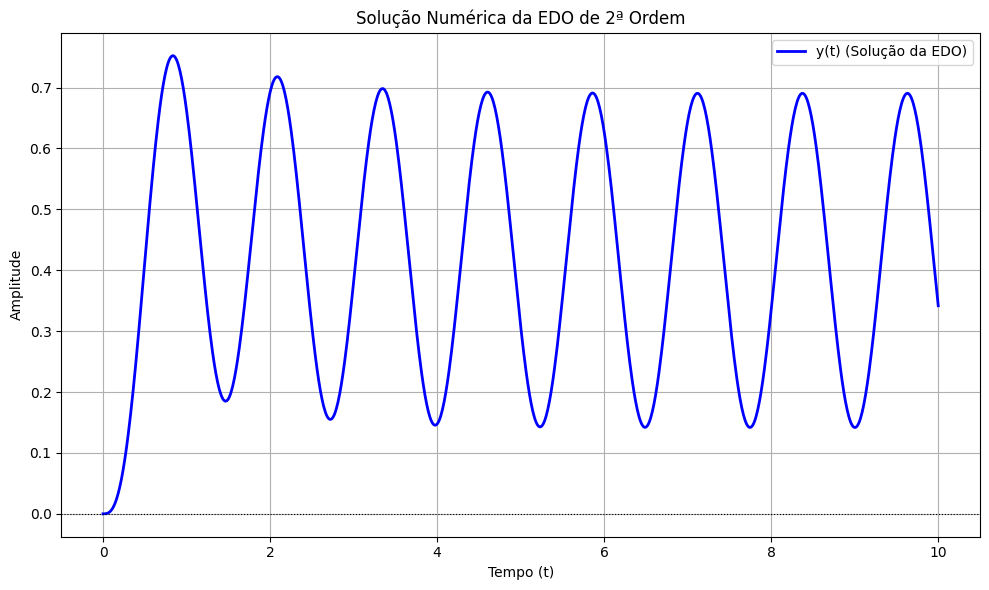

In [33]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

"""
    Temos a equação diferencial: y''(t) + 3y'(t) + e^(-t)y(t) = 8sin(5t).
    Com as condições: y(0) = 0 e y'(0) = 0
    (como há coeficientes variáveis, não poderemos usar soluções simbolicas, 
    então usaremos soluções numericas com scipy e numpy e vamos plotar o gráfico)
"""

# Definir o sistema de EDOs
def modelo(t, Y):
    y1, y2 = Y # y1 é y(t), y2 é y'(t)
    
    # Derivadas (dy1/dt e dy2/dt)
    dy1_dt = y2
    dy2_dt = 8 * np.sin(5 * t) - 3 * y2 - np.exp(-t) * y1
    
    return [dy1_dt, dy2_dt]

# Condições iniciais: y(0) = 0 e y'(0) = 0
Y0 = [0.0, 0.0]

# Gerar pontos de tempo específicos para um gráfico suave
t_eval = np.linspace(0, 10, 1000)

# 4. Resolver a EDO numericamente (usando o método padrão Runge-Kutta 45)
solucao = solve_ivp(modelo, (0, 10), Y0, t_eval=t_eval)

# 5. Plotar os resultados
plt.figure(figsize=(10, 6))

# Plotando y(t)
plt.plot(solucao.t, solucao.y[0], label='y(t) (Solução da EDO)', color='b', linewidth=2)

plt.title('Solução Numérica da EDO de 2ª Ordem')
plt.xlabel('Tempo (t)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Exibir o gráfico
plt.show()


---

**5.** *Achar a resposta para a EDO com coeficientes constantes $\dddot{y} + 4\dot{y} = t$, para as condições iniciais $\dot{y}(0) = y(0) = 0$ e $\ddot{y}(0) = 1$*

In [34]:
import sympy as sp

"""
    Temos a equação diferencial: y''' + 4y' = t
    Com as condições: y(0) = 0,  y'(0) = 0 e y''(0) = 1
    (Como estamos em python, aqui usaremos sympy)
"""

# Declarar a variavel t
t = sp.symbols('t')

# Declarar a função y(t)
y = sp.Function('t')

# Declarar a EDO
edo = sp.Eq(sp.diff(y(t), t, t, t) + 4*sp.diff(y(t), t), t)

# Resolver a EDO para as condições iniciais
solução = sp.dsolve(edo, y(t), ics={y(0):0, sp.diff(y(t), t).subs(t, 0):0, sp.diff(y(t), t, t).subs(t, 0):1})

# Printa a solução
print("Solução:", solução, "\n")

# Printa a solução simbolicamente
print("Solução simbólica:")
sp.pprint(solução)

Solução: Eq(t(t), t**2/8 - 3*cos(2*t)/16 + 3/16) 

Solução simbólica:
        2                  
       t    3⋅cos(2⋅t)   3 
t(t) = ── - ────────── + ──
       8        16       16


---

**6.** *Demonstrar a Equação (15).*

**Resposta:**  

Primeiramente partimos da equação (13): $\ddot{x}(t) + 2\zeta\omega_{n}\dot{x}(t) + \omega^2_{n}x(t) = 0$  
Com $x(0) = x_{0}$ e $\dot{x}(0) = \dot{x}_0$  
Tomamos a transformada de Laplace de cada termo: $(s^2X(s) - sx_{0} - \dot{x}_{0}) + 2\zeta\omega_{n}(sX(s) - x_{0}) + \omega^2_{n}X(s) = 0$  
Isolando $X(s)$: $X(s)(s^2 + 2\zeta\omega_{n}s + \omega^2_{n}) = (s + 2\zeta\omega_{n})x_{0} + \dot{x}_{0}$  
E, finalmente, ao dividir ambos os lados, obtemos:  
$$X(s) =\frac{(s + 2\zeta\omega_{n})x_{0} + \dot{x}_{0}}{s^2 + 2\zeta\omega_{n}s + \omega^2_{n}}$$

---

**7.** *Demonstrar a equação (16).*

**Resposta:**  

Primeiramente vamos completar o quadrado do denominador:  
$s^2 + 2\zeta\omega_{n}s + \omega^2_{n} = (s + \zeta\omega_{n})^2 + \omega^2_{n}(1 - \zeta^2) = (s + \zeta\omega_{n})^2 + \omega^2_{d}$  
Agora, reorganizando o numerador:
$(s + 2\zeta\omega_{n})x_{0} + \dot{x}_{0} = (s + \zeta\omega_{n})x_{0} + \zeta\omega_{n}x_{0} + \dot{x}_{0}$  
Substituinado na Fração original:  
$$X(s) = \frac{(s + \zeta\omega_n)x_0}{(s + \zeta\omega_n)^2 + \omega_d^2} + \frac{\zeta\omega_n x_0 + \dot{x}_0}{(s + \zeta\omega_n)^2 + \omega_d^2}$$
Organizando para que fique análogo às transformadas do seno e cosseno:  
$$X(s) = x_0 \left[ \frac{s + \zeta\omega_n}{(s + \zeta\omega_n)^2 + \omega_d^2} \right] + \frac{\zeta\omega_n x_0 + \dot{x}_0}{\omega_d} \left[ \frac{\omega_d}{(s + \zeta\omega_n)^2 + \omega_d^2} \right]$$
Finalmente, aplicando a transformada inversa e colocando o termo exponencial em evidência:  
$$x(t) = e^{-\zeta\omega_n t} \left[ x_0 \cos(\omega_d t) + \frac{\zeta\omega_n x_0 + \dot{x}_0}{\omega_d} \sin(\omega_d t) \right]$$




---

**8.** *Considere o sistema da Figura 8 cujo modelo matemático foi obtido no Tutorial 3 (Exercício 2). Assumindo m = 100kg, c = 50N.s/m e k = 1200N/m, determine:*  
*a) Rigidez equivalente em N/m.*  
*b) Frequência natural em Hz.*  
*c) Fator de mortecimento.*  
*d) Tipo de resposta livre.*  
*e) Equação da resposta livre, sendo as condições iniciais dadas por um deslocamento
angular inicial θ(0) = 0.15rad e velocidade inicial nula.*

**Resposta:**  

O sistema encontrado foi: $m \ddot{\theta}(t) + c \dot{\theta}(t) + \frac{4}{9} k \theta(t) = 0$  
Substituindo os valores: $100\ddot{\theta}(t) + 50\dot{\theta}(t) + \frac{1600}{3} \theta(t) = 0$  

**a)** A rigidez equivalente é: $\frac{1600}{3} \approx \mathbf{533,33 N/m}$  
**b)** Primeiro calculamos a frequencia angular: $\omega_n = \sqrt{\frac{K_{eq}}{M}} = \sqrt{\frac{1600/3}{100}} = \sqrt{\frac{16}{3}} = \frac{4}{\sqrt{3}} \approx 2,309 \text{ rad/s}$  
Agora vamos converter para Hertz: $f_n = \frac{\omega_n}{2\pi} = \frac{2,309}{2 \cdot 3,1415} \approx \mathbf{0,367 \text{ Hz}}$  
**c)** O fator de amortecimento $(\zeta)$ é dado pela razão entre o amortecimento real e o crítico: $\zeta = \frac{C}{2M\omega_n} = \frac{50}{2 \cdot 100 \cdot 2,309} \approx \mathbf{0,108}$  
**d)** Como o valor de $\zeta$ está entre 0 e 1, o sistema é classificado como **Subamortecido**.  
**e)** Com a velocidade inicial nula, a equação simplificada se torna:  
$$\theta(t) = e^{-\zeta\omega_n t} \left[ \theta_0 \cos(\omega_d t) + \frac{\zeta\omega_n \theta_0}{\omega_d} \sin(\omega_d t) \right]$$
Agora, para encontrar a equação da resposta livre  
Primeiramente calculamos $\omega_{d}$: $\omega_d = \omega_n \sqrt{1 - \zeta^2} = 2,309 \sqrt{1 - 0,108^2} \approx 2,295 \text{ rad/s}$  
Depois os coeficientes: $\theta_{0} = 0,15$; $\zeta\omega_n = 0,108 \cdot 2,309 \approx 0,25$ e o coeficiente do seno $\frac{0,25 \cdot 0,15}{2,295} \approx 0,0163$  
E, finalmente, substituindo tudo:  
$$\mathbf{\theta(t) = e^{-0,25t} \left[ 0,15 \cos(2,295t) + 0,0163 \sin(2,295t) \right] \text{ rad}}$$

---

**9.** *Dado o sistema com polia da Figura 9, cujo modelo matemático foi obtido no Tutorial 3
(Exercício 2), calcule:*  
*a) Rigidez equivalente em N/m.*  
*b) Frequência natural em Hz.* 

**Resposta:**  

O modelo deduzido no tutorial 3 é:  
$$m\ddot{x}(t) + \frac{k}{4}x(t) = 0$$

**a)** A rigidez equivalente é o termo que multiplica o deslocamento. Então de acordo com a dedução do item do tutorial 3, Temos que a rigidez equivalente é $\mathbf{\frac{k}{4}}$

**b)** A frequência natural angular ($\omega_n$) é dada por $\omega_n = \sqrt{\frac{k_{eq}}{m}} = \sqrt{\frac{k}{4m}} = \frac{1}{2}\sqrt{\frac{k}{m}} \text{ rad/s}$. Substituindo para encontrar a frequência em Hertz: $$f_n = \frac{1}{2\pi} \cdot \frac{1}{2}\sqrt{\frac{k}{m}} = \mathbf{\frac{1}{4\pi}\sqrt{\frac{k}{m}} \text{ Hz}}$$

---

**10.** *Simular no MatLab (usaremos python) a oscilação subamortecida correspondente à Figura 4. Usar a equaçãoo (16) com os dados apresentados na figura. Comparar o seu gráfico com o da apostila*  

Equação 16:  
$$x(t) = e^{-\zeta\omega_n t} \left[ x_0 \cos(\omega_d t) + \frac{\zeta\omega_n x_0 + \dot{x}_0}{\omega_d} \sin(\omega_d t) \right]$$
Substituindo os dados:  
$$x(t) = e^{-0.5t}\cdot0.040 \sin(4.97 t)$$

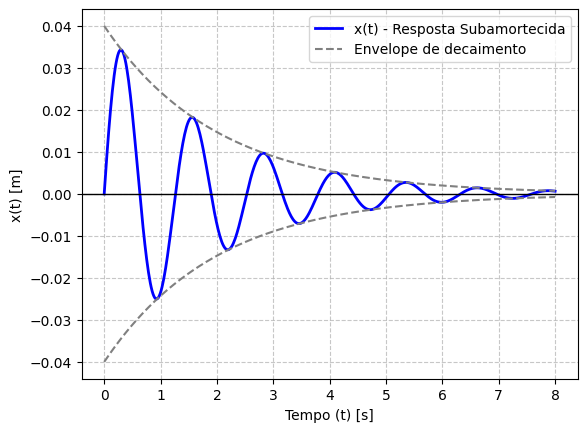

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Declaração do vetor de tempo
t = np.linspace(0, 8, 500)

# Declaração do sinal oscilatório
xt = np.exp(-0.5*t) * 0.04 * np.sin(4.97*t)

# Declaraação das curvas envelopes
exp_superior = 0.040 * np.exp(-0.5 * t)
exp_inferior = -0.040 * np.exp(-0.5 * t)

# Plotagem
plt.plot(t, xt, label='x(t) - Resposta Subamortecida', color='blue', linewidth=2)

plt.plot(t, exp_superior, linestyle='--', color='gray', label='Envelope de decaimento')
plt.plot(t, exp_inferior, linestyle='--', color='gray')

plt.xlabel('Tempo (t) [s]')
plt.ylabel('x(t) [m]')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.legend()

plt.show()

**11.** *Simular no MatLab (usaremos pyhton) o movimento criticamente amortecido correspondente à Figura 5. Usar a equaçãoo (17) com os dados apresentados na figura. Comparar o seu gráfico com o da apostila.*  

Equação (17):
$$x(t) = e^{- \omega_n t} \left[ x_0 + (\omega_n x_0 + \dot{x}_0)t\right]$$
Substituindo dados:  
velocidade inicial = 0.2m/s: $x(t) = e^{- 2 t} \cdot 0.2t$  
velocidade inicial = 0.12m/s: $x(t) = e^{- 2 t} \cdot 0.12t$  
velocidade inicial = 0.04m/s: $x(t) = e^{- 2 t} \cdot 0.04t$

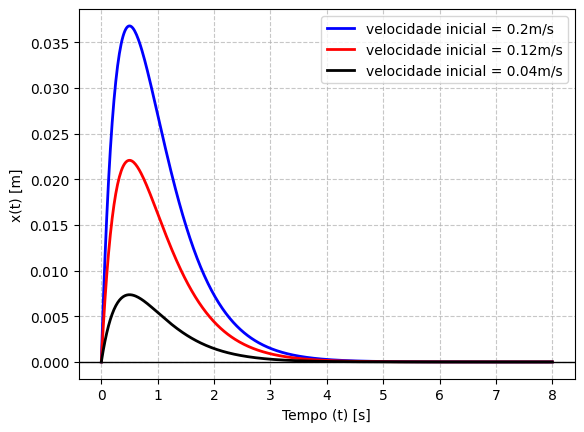

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Declaração do vetor de tempo
t = np.linspace(0, 8, 500)

# Declaração dos sinais
x1 = np.exp(-2*t) * 0.2 * t
x2 = np.exp(-2*t) * 0.12 * t
x3 = np.exp(-2*t) * 0.04 * t

# Plotagem
plt.figure()
plt.plot(t, x1, label='velocidade inicial = 0.2m/s', color='blue', linewidth=2)
plt.plot(t, x2, label='velocidade inicial = 0.12m/s', color='red', linewidth=2)
plt.plot(t, x3, label='velocidade inicial = 0.04m/s', color='black', linewidth=2)


plt.xlabel('Tempo (t) [s]')
plt.ylabel('x(t) [m]')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.legend()

plt.show()

**12.** *Simular no MatLab (usaremos python) o movimento superamortecido correspondente à Figura 6. Usar a equação (14) para calular s1 e s2. Usar as condições iniciais dadas na Figura 5 para calcular as constantes de integração c1 e c2. Usar a equação (18) para realizar a simulação.
Comparar o seu gráfico com o da apostila.*

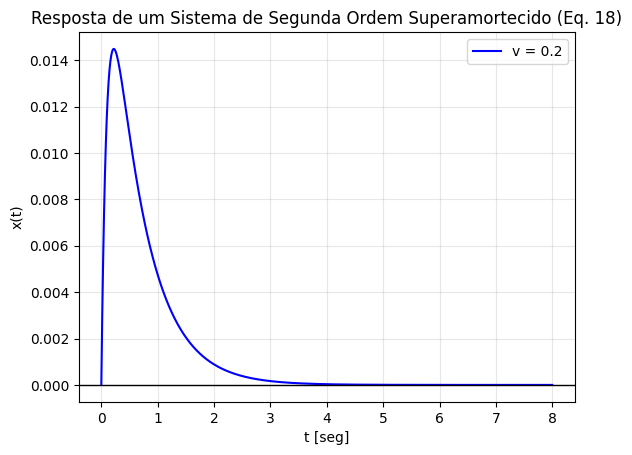

'\n    Como foi fornecido apenas um valor de velocidade no gráfico da figura 6, foi gerado apenas um sinal,\n     em vez de três, como estranhamente é desenhado na figura 6.\n'

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simular_superamortecido(zeta, wn, x0, v0, label):
    # 1. Calcular as raízes s1 e s2 (Eq. 14)
    raiz_termo = wn * np.sqrt(zeta**2 - 1)
    s1 = -zeta * wn + raiz_termo
    s2 = -zeta * wn - raiz_termo
    
    # 2. Calcular constantes c1 e c2 pelas condições iniciais
    # Sistema: 
    # c1 + c2 = x0
    # s1*c1 + s2*c2 = v0
    c2 = (v0 - s1 * x0) / (s2 - s1)
    c1 = x0 - c2
    
    # 3. Gerar vetor de tempo e calcular x(t) (Eq. 18)
    t = np.linspace(0, 8, 1000)
    xt = c1 * np.exp(s1 * t) + c2 * np.exp(s2 * t)
    
    return t, xt

# Parâmetros de exemplo para reproduzir a Figura 6
wn = 4   # Frequência natural
x0 = 0.0    # Posição inicial
v0 = 0.2    # Velocidade inicial (conforme legenda da Fig 6)
zeta = 1.4  # Fator de amortecimento

plt.figure()

t, xt = simular_superamortecido(zeta, wn, x0, v0, f'zeta={zeta}')
plt.plot(t, xt, label=f'v = 0.2', color='blue')

# Configurações do gráfico
plt.title('Resposta de um Sistema de Segunda Ordem Superamortecido (Eq. 18)')
plt.xlabel('t [seg]')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=1)
plt.show()

"""
    Como foi fornecido apenas um valor de velocidade no gráfico da figura 6, foi gerado apenas um sinal,
     em vez de três, como estranhamente é desenhado na figura 6.
"""

---

**13** *Simular no MatLab (usaremos python) o movimento sem amortecimento correspondente à Figura 7. Usar a equação (19) com os dados ωn = 5rad/s, x0 = 0 e x'0 = 0.2m/s. Comparar o seu gráfico com o da apostila.*  

O modelo matemático é dado por:
$$x(t) = x_0 \cos(\omega_n t) + \frac{\dot{x}_0}{\omega_n} \text{sen}(\omega_n t) \quad (19)$$
Substituindo os valores obtemos:
$$x(t) = 0 \cdot \cos(5t) + \frac{0,2}{5} \text{sen}(5t) = 0,04 \text{sen}(5t)$$

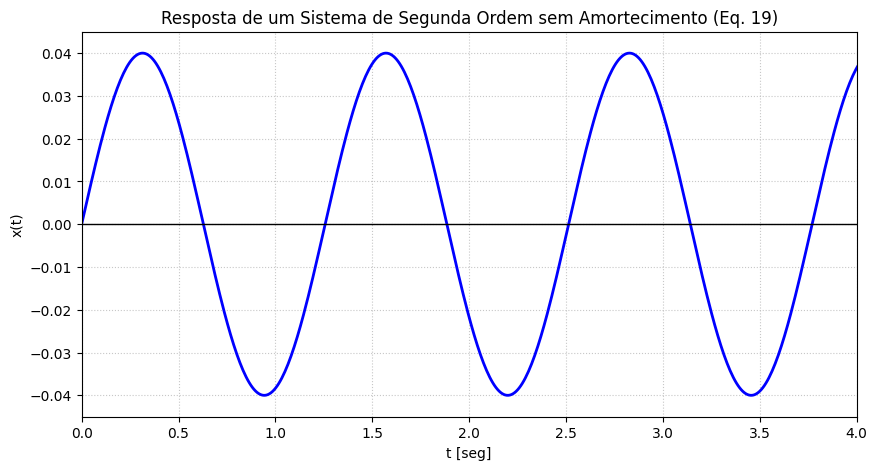

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros fornecidos
wn = 5.0      # rad/s
x0 = 0.0      # m
v0 = 0.2      # m/s

# Definição do tempo (0 a 4 segundos conforme Figura 7)
t = np.linspace(0, 8, 1000)

# Equação (19) - Movimento sem amortecimento
xt = x0 * np.cos(wn * t) + (v0 / wn) * np.sin(wn * t)

# Criação do gráfico
plt.figure(figsize=(10, 5))
plt.plot(t, xt, color='blue', linewidth=2)

# Configurações de exibição para comparar com a apostila
plt.title('Resposta de um Sistema de Segunda Ordem sem Amortecimento (Eq. 19)')
plt.xlabel('t [seg]')
plt.ylabel('x(t)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.xlim(0, 4)
plt.ylim(-0.045, 0.045) # Ajustado para visualizar a amplitude de 0.04
plt.show()